<a href="https://colab.research.google.com/github/lcandau/histopathology-clip-lab/blob/exp_08_plip_backbone/experiments/exp_07_ood_eval/CLIP_PLIP_OOD_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# exp_07 — exp_08 PLIP-backbone OOD evaluation on NCT-CRC-HE-7K

Mirror of `CLIP_OOD_eval.ipynb` for the exp_08 architecture: PLIP vision encoder + BERT text encoder + projection heads. Loads the checkpoint trained by `exp_08_plip_backbone/CLIP_PLIP_BERT.ipynb` and evaluates it on NCT-CRC NORM+TUM (restricted argmax over colon classes `[3, 4]`).

Produces the same 2×3 grid (LC25000 all + NCT  /  LC25000 colon + NCT  /  NCT only  × scatter + thumbnails) used by the other OOD notebooks, so visual comparison across architectures is direct.


## 0 — Bootstrap


In [1]:
# --- Cell 0: bootstrap ---
import os, sys, subprocess
os.environ["KERAS_BACKEND"] = "tensorflow"

REPO_URL = "https://github.com/lcandau/histopathology-clip-lab.git"
REPO_DIR = "/content/histopathology-clip-lab"
BRANCH   = "exp_08_plip_backbone"
IN_COLAB = "google.colab" in sys.modules


def _clone_with_fallback(branch):
    try:
        subprocess.run(
            ["git", "clone", "-b", branch, REPO_URL, REPO_DIR],
            check=True, capture_output=True,
        )
        print(f"Cloned branch {branch!r}")
        return branch
    except subprocess.CalledProcessError:
        print(f"Branch {branch!r} not found; cloning main")
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
        return "main"


if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        active = _clone_with_fallback(BRANCH)
    else:
        fetch = subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", BRANCH], capture_output=True)
        if fetch.returncode == 0:
            subprocess.run(["git", "-C", REPO_DIR, "checkout", BRANCH], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", f"origin/{BRANCH}"], check=True)
            active = BRANCH
        else:
            subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", "main"], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "checkout", "main"], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)
            active = "main"
    print(f"Active branch: {active}")
    subprocess.run([
        "pip", "install", "-q",
        "tensorflow==2.18.0", "keras==3.7.0", "keras-hub==0.18.1",
        "transformers==4.46.0", "umap-learn", "kagglehub",
        "scikit-learn", "matplotlib", "pandas", "Pillow",
    ], check=True)
    subprocess.run(["pip", "uninstall", "-y", "-q", "jax", "jaxlib"], check=False)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
else:
    LOCAL_REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
    if LOCAL_REPO_DIR not in sys.path:
        sys.path.insert(0, LOCAL_REPO_DIR)

print("In Colab:", IN_COLAB)
print("sys.path[0]:", sys.path[0])
print("KERAS_BACKEND:", os.environ.get("KERAS_BACKEND"))


Cloned branch 'exp_08_plip_backbone'
Active branch: exp_08_plip_backbone
Mounted at /content/drive
In Colab: True
sys.path[0]: /content/histopathology-clip-lab
KERAS_BACKEND: tensorflow


## 1 — Imports


In [2]:
# --- Cell 1: imports ---
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import json
import math
import shutil
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
import keras

from transformers import AutoTokenizer, TFAutoModel, TFCLIPVisionModel

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score,
)

from src.utils.paths import is_colab, repo_root, drive_root, run_dir, results_dir
from src.utils.repro import set_global_seed, enable_op_determinism
from src.data.lc25000 import (
    CLASS_INFO, NUM_CLASSES, CLASS_NAMES, INDEX_TO_NAME, ID_TO_INDEX,
    discover_records, stratified_split, save_split, load_split,
)
from src.prompts.templates import baseline_prompt


## 2 — Configuration


In [3]:
# --- Cell 2: config ---
EXPERIMENT = "exp_07_ood_eval"
VARIANT    = "plip_bert_composed"
SEED = 42
set_global_seed(SEED)
enable_op_determinism()

IMG_SIZE = 224
MAX_LEN = 24
EMBED_DIM = 256
INIT_TEMP = 0.07
BATCH_SIZE = 64

PLIP_MODEL_ID   = "vinid/plip"
TEXT_ENCODER_ID = "bert-base-uncased"

# PLIP / CLIP-standard image normalisation.
PLIP_MEAN = tf.constant([0.48145466, 0.4578275, 0.40821073], dtype=tf.float32)
PLIP_STD  = tf.constant([0.26862954, 0.26130258, 0.27577711], dtype=tf.float32)

# exp_08 checkpoint.
CHECKPOINT_PATH = run_dir("exp_08_plip_backbone", "plip_bert_composed") / "weights.weights.h5"

# NCT-CRC-HE-7K.
NCT_URL  = "https://zenodo.org/records/1214456/files/CRC-VAL-HE-7K.zip"
NCT_NAME = "CRC-VAL-HE-7K"
NCT_TO_LC25000 = {
    "NORM": "benign colon tissue",
    "TUM":  "colon adenocarcinoma",
}
DRIVE_OOD_ZIP   = drive_root() / "ood_datasets" / f"{NCT_NAME}.zip"
LOCAL_OOD_ROOT  = Path("/content/ood_data") if is_colab() else Path("/tmp/ood_data")
LOCAL_OOD_DIR   = LOCAL_OOD_ROOT / NCT_NAME

METRICS_DIR = results_dir("metrics") / EXPERIMENT
CM_DIR      = results_dir("confusion_matrices") / EXPERIMENT
PLOTS_DIR   = results_dir("plots") / EXPERIMENT
for d in (METRICS_DIR, CM_DIR, PLOTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Variant:    {VARIANT}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Local OOD:  {LOCAL_OOD_DIR}")


Variant:    plip_bert_composed
Checkpoint: /content/drive/MyDrive/clip_histopathology/exp_08_plip_backbone/plip_bert_composed/weights.weights.h5
Local OOD:  /content/ood_data/CRC-VAL-HE-7K


## 3 — Acquire NCT-CRC-HE-7K


In [4]:
# --- Cell 3: download / extract NCT-CRC ---
def _ensure_nct_zip(path):
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists(): return path
    DRIVE_OOD_ZIP.parent.mkdir(parents=True, exist_ok=True)
    if DRIVE_OOD_ZIP.exists():
        shutil.copy(DRIVE_OOD_ZIP, path); return path
    print(f"Downloading NCT-CRC from {NCT_URL} ...")
    urllib.request.urlretrieve(NCT_URL, path)
    shutil.copy(path, DRIVE_OOD_ZIP)
    return path


nct_zip_local = LOCAL_OOD_ROOT / f"{NCT_NAME}.zip"
_ensure_nct_zip(nct_zip_local)
if not LOCAL_OOD_DIR.exists() or not any(LOCAL_OOD_DIR.iterdir()):
    print(f"Extracting {nct_zip_local} -> {LOCAL_OOD_ROOT}")
    with zipfile.ZipFile(nct_zip_local) as zf:
        zf.extractall(LOCAL_OOD_ROOT)
print(f"\nClasses on disk:")
for cd in sorted(p for p in LOCAL_OOD_DIR.iterdir() if p.is_dir()):
    print(f"  {cd.name:>5s}  ({len(list(cd.iterdir()))} tiles)")


Extracting /content/ood_data/CRC-VAL-HE-7K.zip -> /content/ood_data

Classes on disk:
    ADI  (1338 tiles)
   BACK  (847 tiles)
    DEB  (339 tiles)
    LYM  (634 tiles)
    MUC  (1035 tiles)
    MUS  (592 tiles)
   NORM  (741 tiles)
    STR  (421 tiles)
    TUM  (1233 tiles)


## 4 — Discover OOD records (NORM + TUM)


In [5]:
# --- Cell 4: discover OOD records ---
ood_paths = []
ood_nct_labels = []
for nct_cls in NCT_TO_LC25000:
    class_dir = LOCAL_OOD_DIR / nct_cls
    for f in sorted(class_dir.iterdir()):
        if f.suffix.lower() in {".tif", ".tiff", ".png", ".jpg", ".jpeg"}:
            ood_paths.append(str(f))
            ood_nct_labels.append(nct_cls)

ood_paths = np.asarray(ood_paths)
ood_nct_labels = np.asarray(ood_nct_labels)
ood_lc_indices = np.array([
    ID_TO_INDEX[next(c.id for c in CLASS_INFO if c.name == NCT_TO_LC25000[lab])]
    for lab in ood_nct_labels
], dtype=np.int32)

COLON_IDX = sorted({
    ID_TO_INDEX[next(c.id for c in CLASS_INFO if c.name == NCT_TO_LC25000[lab])]
    for lab in NCT_TO_LC25000
})

print(f"Total OOD tiles: {len(ood_paths)}  "
      f"(NORM={int((ood_nct_labels=='NORM').sum())}, TUM={int((ood_nct_labels=='TUM').sum())})")
print(f"Colon class indices: {COLON_IDX}")


Total OOD tiles: 1974  (NORM=741, TUM=1233)
Colon class indices: [3, 4]


## 5 — Rebuild CLIPModel_PLIP architecture + load weights


In [6]:
# --- Cell 5: load PLIP vision + BERT text + CLIPModel_PLIP ---
def _load_plip_vision():
    try:
        m = TFCLIPVisionModel.from_pretrained(PLIP_MODEL_ID, from_pt=False)
    except (OSError, EnvironmentError, TypeError, ValueError):
        m = TFCLIPVisionModel.from_pretrained(PLIP_MODEL_ID, from_pt=True)
    m.trainable = False
    return m


def _load_bert_text(encoder_id=TEXT_ENCODER_ID):
    tokenizer = AutoTokenizer.from_pretrained(encoder_id)
    try:
        m = TFAutoModel.from_pretrained(encoder_id, from_pt=False)
    except (OSError, EnvironmentError, TypeError, ValueError):
        m = TFAutoModel.from_pretrained(encoder_id, from_pt=True)
    m.trainable = False
    return m, tokenizer, m.config.hidden_size


print("Loading PLIP vision encoder...")
plip_vision = _load_plip_vision()
print("Loading BERT text encoder...")
text_backbone, tokenizer, text_hidden = _load_bert_text()


def tokenize_prompts(tokenizer, prompts, max_len=MAX_LEN):
    out = tokenizer(prompts, padding="max_length", truncation=True,
                    max_length=max_len, return_tensors="tf")
    return {k: tf.cast(v, tf.int32) for k, v in out.items()}


class CLIPModel_PLIP(keras.Model):
    def __init__(self, vision_model, text_backbone, vision_hidden, text_hidden,
                 embed_dim=EMBED_DIM, init_temp=INIT_TEMP, **kwargs):
        super().__init__(**kwargs)
        self.vision_model = vision_model
        self.text_backbone = text_backbone
        self.img_projection = keras.Sequential([
            keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
            keras.layers.LayerNormalization(dtype="float32"),
        ], name="img_projection")
        self.text_projection = keras.Sequential([
            keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
            keras.layers.LayerNormalization(dtype="float32"),
        ], name="text_projection")
        self.logit_scale = self.add_weight(
            name="logit_scale", shape=(),
            initializer=keras.initializers.Constant(math.log(1.0 / init_temp)),
            trainable=True, dtype="float32",
        )
        self.loss_tracker = keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def encode_image(self, pixel_values, training=False):
        # HF's TFCLIPVisionEmbeddings expects NCHW (PyTorch convention) — transpose
        # NHWC (TF default, what tf.data produces) -> NCHW before the vision encoder.
        pixel_values = tf.transpose(pixel_values, perm=[0, 3, 1, 2])
        out = self.vision_model(pixel_values=pixel_values, training=False)
        features = out.pooler_output
        x = self.img_projection(features)
        return tf.math.l2_normalize(x, axis=-1)

    def encode_text(self, token_dict, training=False):
        kwargs = {"input_ids": token_dict["input_ids"],
                  "attention_mask": token_dict["attention_mask"]}
        if "token_type_ids" in token_dict:
            kwargs["token_type_ids"] = token_dict["token_type_ids"]
        out = self.text_backbone(**kwargs, training=False)
        pooled = getattr(out, "pooler_output", None)
        if pooled is None:
            pooled = out.last_hidden_state[:, 0, :]
        x = self.text_projection(pooled)
        return tf.math.l2_normalize(x, axis=-1)

    def call(self, inputs, training=False):
        pixel_values, token_dict = inputs
        return self.encode_image(pixel_values, training=training), self.encode_text(token_dict, training=training)


model = CLIPModel_PLIP(plip_vision, text_backbone, plip_vision.config.hidden_size, text_hidden)

# Warm-up forward pass before load_weights.
class_prompts = [baseline_prompt(name) for name in CLASS_NAMES]
class_token_dict = tokenize_prompts(tokenizer, class_prompts)
dummy_imgs   = tf.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32)
dummy_tokens = {k: tf.constant(v[:1]) for k, v in class_token_dict.items()}
_ = model((dummy_imgs, dummy_tokens), training=False)

assert CHECKPOINT_PATH.is_file(), (
    f"Missing checkpoint at {CHECKPOINT_PATH}.\n"
    f"Run experiments/exp_08_plip_backbone/CLIP_PLIP_BERT.ipynb first."
)
model.load_weights(str(CHECKPOINT_PATH))
print(f"Loaded weights from {CHECKPOINT_PATH}")

n_trainable = sum(int(np.prod(v.shape)) for v in model.trainable_variables)
print(f"Trainable params: {n_trainable:,}")


Loading PLIP vision encoder...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFCLIPVisionModel: ['text_model.encoder.layers.1.mlp.fc2.bias', 'text_model.encoder.layers.0.self_attn.v_proj.bias', 'text_model.encoder.layers.7.mlp.fc1.bias', 'text_model.encoder.layers.6.layer_norm2.bias', 'text_model.encoder.layers.4.self_attn.out_proj.bias', 'text_model.encoder.layers.1.self_attn.q_proj.bias', 'text_model.encoder.layers.8.self_attn.q_proj.bias', 'text_model.encoder.layers.10.self_attn.k_proj.bias', 'text_model.encoder.layers.5.self_attn.q_proj.bias', 'text_model.encoder.layers.1.self_attn.v_proj.weight', 'text_model.encoder.layers.1.layer_norm2.bias', 'text_model.encoder.layers.11.self_attn.q_proj.weight', 'text_model.encoder.layers.1.self_attn.k_proj.weight', 'text_model.encoder.layers.2.layer_norm2.bias', 'text_model.encoder.layers.4.mlp.fc2.bias', 'text_model.encoder.layers.5.self_attn.v_proj.weight', 'text_model.encoder.layers.3.layer_norm2.weight', 'text_model.encoder.layers.1.

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Loaded weights from /content/drive/MyDrive/clip_histopathology/exp_08_plip_backbone/plip_bert_composed/weights.weights.h5
Trainable params: 394,241


## 6 — Encode NCT tiles + classify


In [7]:
# --- Cell 6: encode OOD + classify ---
def load_pixel_values_plip(path):
    img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    arr = (arr - np.array([0.48145466, 0.4578275, 0.40821073], dtype=np.float32)) \
          / np.array([0.26862954, 0.26130258, 0.27577711], dtype=np.float32)
    return arr


def encode_paths(paths, batch_size=BATCH_SIZE):
    out = []
    for start in range(0, len(paths), batch_size):
        batch_paths = paths[start:start + batch_size]
        batch_arrs = [load_pixel_values_plip(p) for p in batch_paths]
        emb = model.encode_image(tf.constant(np.stack(batch_arrs)), training=False).numpy()
        out.append(emb)
    return np.concatenate(out, axis=0)


print(f"Encoding {len(ood_paths)} OOD tiles...")
ood_embeddings = encode_paths(ood_paths)
print(f"OOD embeddings shape: {ood_embeddings.shape}")

prompt_embeddings_all = model.encode_text(class_token_dict, training=False).numpy()

sims_all = ood_embeddings @ prompt_embeddings_all.T
sims_colon = sims_all[:, COLON_IDX]
pred_within_colon = sims_colon.argmax(axis=1)
y_pred = np.array([COLON_IDX[i] for i in pred_within_colon], dtype=np.int32)
y_true = ood_lc_indices

print(f"y_pred unique: {sorted(set(y_pred.tolist()))}")
print(f"y_true unique: {sorted(set(y_true.tolist()))}")


Encoding 1974 OOD tiles...
OOD embeddings shape: (1974, 256)
y_pred unique: [3, 4]
y_true unique: [3, 4]


## 7 — Metrics + confusion matrix


OOD (plip_bert_composed -> NCT-CRC-HE-7K, NORM + TUM)

  accuracy          = 0.9377
  balanced accuracy = 0.9272
  macro F1          = 0.9327
  weighted F1       = 0.9373

Per-class:
                      precision  recall  f1-score    support
benign colon tissue      0.9452  0.8853    0.9143   741.0000
colon adenocarcinoma     0.9336  0.9692    0.9511  1233.0000
accuracy                 0.9377  0.9377    0.9377     0.9377
macro avg                0.9394  0.9272    0.9327  1974.0000
weighted avg             0.9380  0.9377    0.9373  1974.0000

Saved /content/histopathology-clip-lab/results/metrics/exp_07_ood_eval/plip_bert_composed_ood_classification.json


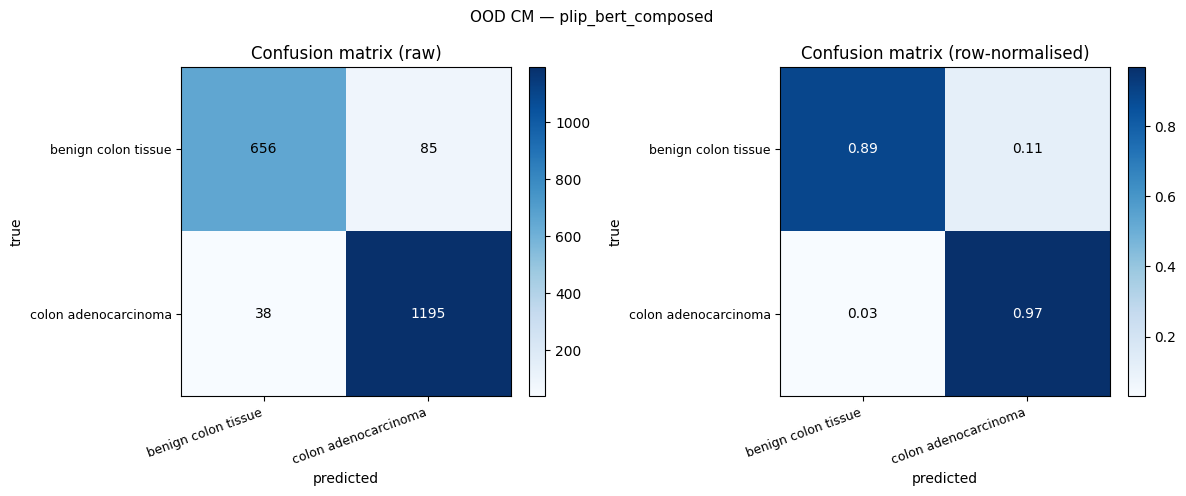

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/plip_bert_composed_ood_cm.png


In [8]:
# --- Cell 7: metrics + CM ---
labels = COLON_IDX
target_names = [INDEX_TO_NAME[i] for i in labels]

acc      = accuracy_score(y_true, y_pred)
bal      = balanced_accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
wgt_f1   = f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)

print(f"OOD ({VARIANT} -> NCT-CRC-HE-7K, NORM + TUM)\n")
print(f"  accuracy          = {acc:.4f}")
print(f"  balanced accuracy = {bal:.4f}")
print(f"  macro F1          = {macro_f1:.4f}")
print(f"  weighted F1       = {wgt_f1:.4f}")

per_class = classification_report(y_true, y_pred, labels=labels,
                                   target_names=target_names,
                                   output_dict=True, zero_division=0)
print("\nPer-class:")
print(pd.DataFrame(per_class).T.round(4).to_string())

cm_raw = confusion_matrix(y_true, y_pred, labels=labels)
row_sums = cm_raw.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_raw, row_sums, where=row_sums > 0,
                    out=np.zeros_like(cm_raw, dtype=np.float64))

metrics_payload = {
    "experiment":          EXPERIMENT,
    "variant":             VARIANT,
    "checkpoint":          str(CHECKPOINT_PATH),
    "ood_dataset":         NCT_NAME,
    "n_tiles":             int(len(ood_paths)),
    "accuracy":            float(acc),
    "balanced_accuracy":   float(bal),
    "macro_f1":            float(macro_f1),
    "weighted_f1":         float(wgt_f1),
    "per_class":           per_class,
    "colon_indices":       labels,
    "target_names":        target_names,
}
metrics_path = METRICS_DIR / f"{VARIANT}_ood_classification.json"
metrics_path.write_text(json.dumps(metrics_payload, indent=2))
np.save(CM_DIR / f"{VARIANT}_ood_cm_raw.npy",  cm_raw)
np.save(CM_DIR / f"{VARIANT}_ood_cm_norm.npy", cm_norm)
print(f"\nSaved {metrics_path}")


# Plot CMs.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mat, title, fmt, cmap in [
    (axes[0], cm_raw,  "Confusion matrix (raw)",         "d",   "Blues"),
    (axes[1], cm_norm, "Confusion matrix (row-normalised)", ".2f", "Blues"),
]:
    im = ax.imshow(mat, cmap=cmap)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(target_names, rotation=20, ha="right", fontsize=9)
    ax.set_yticklabels(target_names, fontsize=9)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(title)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center",
                    color="white" if mat[i, j] > mat.max() * 0.6 else "black", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f"OOD CM — {VARIANT}", fontsize=11)
plt.tight_layout()
cm_path = PLOTS_DIR / f"{VARIANT}_ood_cm.png"
fig.savefig(cm_path, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {cm_path}")


## 8 — Load LC25000 + encode + fit shared UMAP

Same approach as the other OOD eval notebooks. Encodes the full LC25000 test set + NCT + 5 prompts into a single UMAP coordinate system so the 2×3 grid panels can share the same `(x, y)`.


In [9]:
# --- Cell 8: shared UMAP fit ---
import umap
import kagglehub

LC_SPLIT_PATH = results_dir("splits") / f"lc25000_seed{SEED}.json"
if LC_SPLIT_PATH.exists():
    lc_split = load_split(LC_SPLIT_PATH)
    print(f"Loaded split from {LC_SPLIT_PATH}")
else:
    print("Downloading LC25000 via kagglehub...")
    lc_root = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")
    all_paths, all_indices = discover_records(lc_root)
    lc_split = stratified_split(all_paths, all_indices,
                                val_fraction=0.10, test_fraction=0.10, seed=SEED)
    save_split(lc_split, LC_SPLIT_PATH)

lc_test_paths   = np.asarray(lc_split["test_paths"])
lc_test_indices = np.asarray(lc_split["test_indices"], dtype=np.int32)
lc_colon_mask   = np.isin(lc_test_indices, COLON_IDX)
lc_colon_paths   = lc_test_paths[lc_colon_mask]
lc_colon_indices = lc_test_indices[lc_colon_mask]

print(f"\nEncoding {len(lc_test_paths)} LC25000 test images (with PLIP preprocessing)...")
lc_test_embeddings = encode_paths(lc_test_paths)
print(f"LC25000 embeddings: {lc_test_embeddings.shape}")

print(f"\nFitting combined UMAP over {len(lc_test_embeddings) + len(ood_embeddings) + 5} points...")
combined = np.vstack([lc_test_embeddings, ood_embeddings, prompt_embeddings_all])
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED)
combined_2d = reducer.fit_transform(combined)

n_lc, n_nct = len(lc_test_embeddings), len(ood_embeddings)
lc_2d           = combined_2d[:n_lc]
nct_2d          = combined_2d[n_lc:n_lc + n_nct]
prompt_2d       = combined_2d[n_lc + n_nct:]
lc_colon_2d     = lc_2d[lc_colon_mask]
prompt_2d_colon = prompt_2d[COLON_IDX]


Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.

Encoding 2372 LC25000 test images (with PLIP preprocessing)...
LC25000 embeddings: (2372, 256)

Fitting combined UMAP over 4351 points...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## 9 — 2×3 grid: LC + NCT  /  LC colon + NCT  /  NCT only  (×scatter, ×thumbnails)


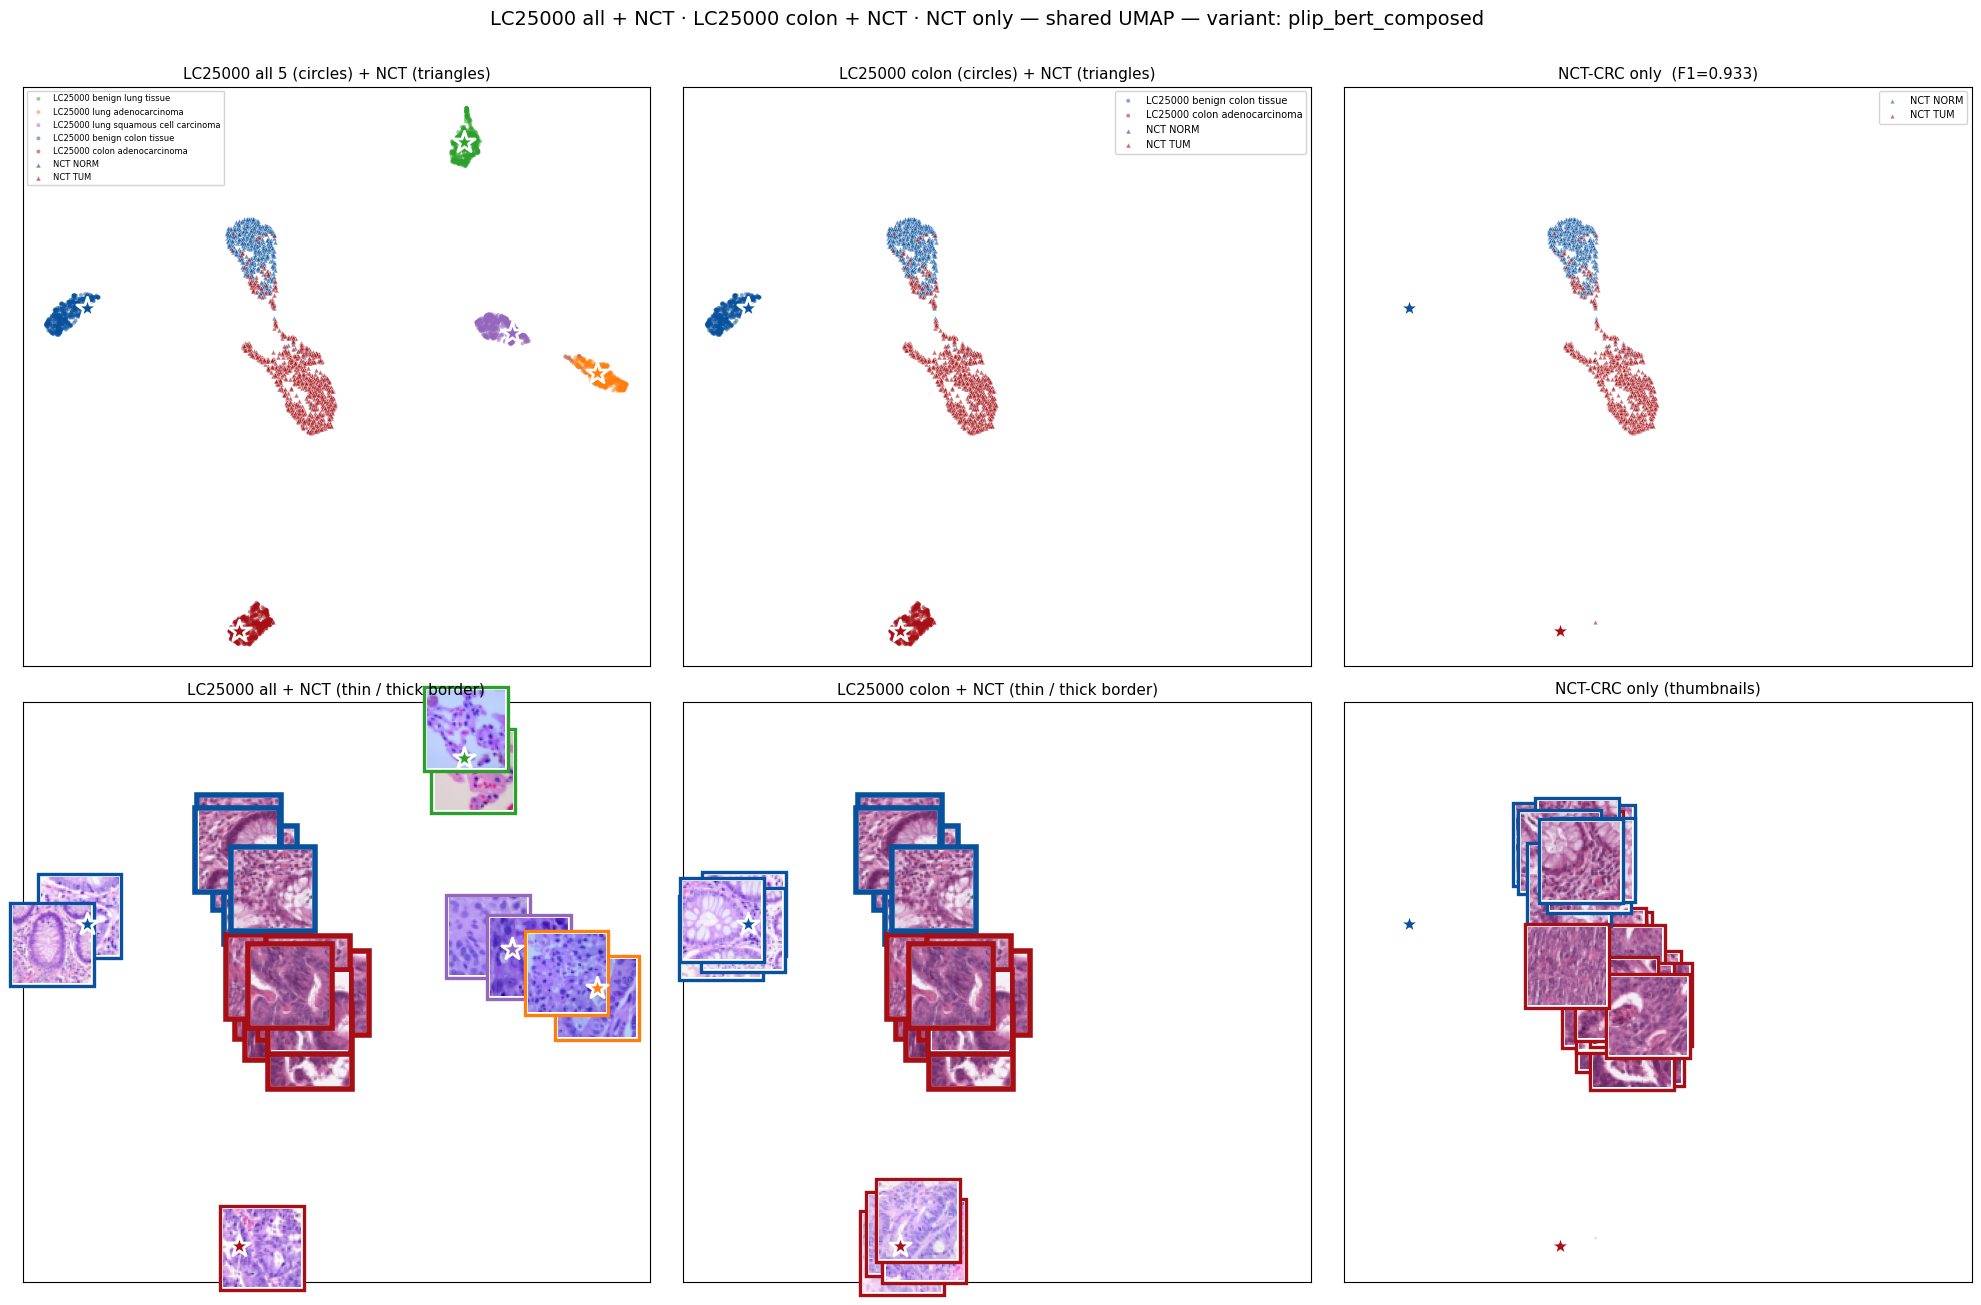

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/plip_bert_composed_ood_umap_grid.png


In [10]:
# --- Cell 9: 2x3 grid ---
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from matplotlib.patches import Patch

CLASS_COLOR = {
    0: "#2ca02c",  # benign lung
    1: "#ff7f0e",  # lung adeno
    2: "#9467bd",  # lung SCC
    3: "#08519c",  # benign colon
    4: "#a50f15",  # colon adeno
}
BENIGN_COLOR = CLASS_COLOR[3]
ADENO_COLOR  = CLASS_COLOR[4]


def draw_prompt_stars(ax, prompt_pos, prompt_indices, *, with_labels=False, size=260):
    for k, idx in enumerate(prompt_indices):
        color = CLASS_COLOR[idx]
        ax.scatter(prompt_pos[k, 0], prompt_pos[k, 1], s=size, marker="*",
                   c=color, edgecolors="white", linewidths=2.0, zorder=6)
        if with_labels:
            ax.annotate(f"prompt:\n{INDEX_TO_NAME[idx]}",
                        (prompt_pos[k, 0], prompt_pos[k, 1]),
                        xytext=(12, 10), textcoords="offset points",
                        fontsize=8, fontweight="bold", zorder=7,
                        bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                                  edgecolor=color, alpha=0.9, linewidth=1.5))


def _scatter_nct(ax, alpha=0.55, size=10):
    for nct_cls, color in (("NORM", BENIGN_COLOR), ("TUM", ADENO_COLOR)):
        mask = (ood_nct_labels == nct_cls)
        ax.scatter(nct_2d[mask, 0], nct_2d[mask, 1], s=size, alpha=alpha,
                   c=color, marker="^", label=f"NCT {nct_cls}",
                   edgecolors="white", linewidths=0.3)


def _read_thumb(path, size=(56, 56)):
    try: return np.asarray(Image.open(path).convert("RGB").resize(size, Image.BILINEAR))
    except Exception: return np.full((size[1], size[0], 3), 200, dtype=np.uint8)


def _layout_thumbnails(ax, coords, paths, class_colors, *, max_thumbs=35,
                       thumb_size=(56, 56), min_dist_frac=0.06, seed=42, border_width=2.4):
    coords = np.asarray(coords)
    rng = np.random.default_rng(seed)
    x_range = float(coords[:, 0].max() - coords[:, 0].min())
    y_range = float(coords[:, 1].max() - coords[:, 1].min())
    min_dist = min_dist_frac * min(x_range, y_range)
    idx = np.arange(len(coords)); rng.shuffle(idx)
    placed = []
    for i in idx:
        x, y = float(coords[i, 0]), float(coords[i, 1])
        if any((x - px) ** 2 + (y - py) ** 2 < min_dist ** 2 for (px, py) in placed): continue
        thumb = _read_thumb(paths[i], size=thumb_size)
        ab = AnnotationBbox(OffsetImage(thumb, zoom=1.0), (x, y),
                            frameon=True, pad=0.22,
                            bboxprops=dict(linewidth=border_width, edgecolor=class_colors[i]))
        ax.add_artist(ab)
        placed.append((x, y))
        if len(placed) >= max_thumbs: break
    return len(placed)


fig, axes = plt.subplots(2, 3, figsize=(20, 13))
x_min = min(lc_2d[:, 0].min(), nct_2d[:, 0].min(), prompt_2d[:, 0].min())
x_max = max(lc_2d[:, 0].max(), nct_2d[:, 0].max(), prompt_2d[:, 0].max())
y_min = min(lc_2d[:, 1].min(), nct_2d[:, 1].min(), prompt_2d[:, 1].min())
y_max = max(lc_2d[:, 1].max(), nct_2d[:, 1].max(), prompt_2d[:, 1].max())
pad_x = 0.04 * (x_max - x_min); pad_y = 0.04 * (y_max - y_min)
XLIM = (x_min - pad_x, x_max + pad_x); YLIM = (y_min - pad_y, y_max + pad_y)


def _box(ax, title):
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=11)


# ROW 1: SCATTER
ax = axes[0, 0]
for idx in range(len(CLASS_INFO)):
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=8, alpha=0.5,
               c=CLASS_COLOR[idx], marker="o", label=f"LC25000 {INDEX_TO_NAME[idx]}", edgecolors="none")
_scatter_nct(ax, alpha=0.6, size=12)
draw_prompt_stars(ax, prompt_2d, list(range(len(CLASS_INFO))))
ax.legend(loc="best", fontsize=6, framealpha=0.85)
_box(ax, "LC25000 all 5 (circles) + NCT (triangles)")

ax = axes[0, 1]
for idx in COLON_IDX:
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=8, alpha=0.5,
               c=CLASS_COLOR[idx], marker="o", label=f"LC25000 {INDEX_TO_NAME[idx]}", edgecolors="none")
_scatter_nct(ax, alpha=0.6, size=12)
draw_prompt_stars(ax, prompt_2d_colon, COLON_IDX)
ax.legend(loc="best", fontsize=7, framealpha=0.85)
_box(ax, "LC25000 colon (circles) + NCT (triangles)")

ax = axes[0, 2]
_scatter_nct(ax, alpha=0.6, size=10)
draw_prompt_stars(ax, prompt_2d_colon, COLON_IDX)
ax.legend(loc="best", fontsize=7, framealpha=0.85)
_box(ax, f"NCT-CRC only  (F1={macro_f1:.3f})")


# ROW 2: THUMBNAILS
ax = axes[1, 0]
for idx in range(len(CLASS_INFO)):
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=5, alpha=0.12, c=CLASS_COLOR[idx], marker="o")
_scatter_nct(ax, alpha=0.18, size=5)
_layout_thumbnails(ax, lc_2d, list(lc_test_paths),
    [CLASS_COLOR[int(lc_test_indices[i])] for i in range(len(lc_test_paths))],
    max_thumbs=25, min_dist_frac=0.07, seed=SEED, border_width=2.4)
_layout_thumbnails(ax, nct_2d, list(ood_paths),
    [CLASS_COLOR[int(ood_lc_indices[i])] for i in range(len(ood_paths))],
    max_thumbs=15, min_dist_frac=0.07, seed=SEED + 1, border_width=4.0)
draw_prompt_stars(ax, prompt_2d, list(range(len(CLASS_INFO))))
_box(ax, "LC25000 all + NCT (thin / thick border)")

ax = axes[1, 1]
for idx in COLON_IDX:
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=5, alpha=0.12, c=CLASS_COLOR[idx], marker="o")
_scatter_nct(ax, alpha=0.18, size=5)
_layout_thumbnails(ax, lc_colon_2d, list(lc_colon_paths),
    [CLASS_COLOR[int(lc_colon_indices[i])] for i in range(len(lc_colon_paths))],
    max_thumbs=20, min_dist_frac=0.07, seed=SEED, border_width=2.4)
_layout_thumbnails(ax, nct_2d, list(ood_paths),
    [CLASS_COLOR[int(ood_lc_indices[i])] for i in range(len(ood_paths))],
    max_thumbs=15, min_dist_frac=0.07, seed=SEED + 1, border_width=4.0)
draw_prompt_stars(ax, prompt_2d_colon, COLON_IDX)
_box(ax, "LC25000 colon + NCT (thin / thick border)")

ax = axes[1, 2]
_scatter_nct(ax, alpha=0.20, size=5)
_layout_thumbnails(ax, nct_2d, list(ood_paths),
    [CLASS_COLOR[int(ood_lc_indices[i])] for i in range(len(ood_paths))],
    max_thumbs=30, min_dist_frac=0.06, seed=SEED, border_width=2.4)
draw_prompt_stars(ax, prompt_2d_colon, COLON_IDX)
_box(ax, "NCT-CRC only (thumbnails)")


fig.suptitle(f"LC25000 all + NCT · LC25000 colon + NCT · NCT only — shared UMAP — variant: {VARIANT}",
             fontsize=14, y=1.005)
plt.tight_layout()
p_grid = PLOTS_DIR / f"{VARIANT}_ood_umap_grid.png"
fig.savefig(p_grid, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {p_grid}")


## Summary

Run-time output:
- `results/metrics/exp_07_ood_eval/plip_bert_composed_ood_classification.json`
- `results/confusion_matrices/exp_07_ood_eval/plip_bert_composed_ood_cm_{raw,norm}.npy`
- `results/plots/exp_07_ood_eval/plip_bert_composed_ood_cm.png`
- `results/plots/exp_07_ood_eval/plip_bert_composed_ood_umap_grid.png`

**Comparison target**: the baseline CLIP OOD macro-F1 is 0.866 (frozen ImageNet ResNet50 + BERT). If exp_08 PLIP-backbone beats that meaningfully, the image-encoder bottleneck hypothesis is confirmed and PLIP-pretrained features are providing OOD value beyond what ImageNet provides on this task. If exp_08 lands in the same 0.81–0.88 range, the bottleneck is something else.

**Prereq:** the exp_08 training notebook must have been run first to produce `<RUN_DIR>/weights.weights.h5`.
